<a href="https://colab.research.google.com/github/Sahil-K-Y/AI-ML-Blueprint/blob/main/Phase-6%20-%20Deep%20Learning%20%26%20PyTorch/085_gradient_problems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
from tensorflow import keras

In [8]:
x = 2.0
w = 3.0

y = w * x

print("x =", x)
print("w =", w)
print("y =", y)

x = 2.0
w = 3.0
y = 6.0


In [9]:
dy_dw = x

print("dy/dw =", dy_dw)

dy/dw = 2.0


In [10]:
x = 2.0
w = 3.0

epsilon = 0.0001

y1 = w * x

w_new = w + epsilon
y2 = w_new * x

numerical_gradient = (y2 - y1) / epsilon

print("Original output:", y1)
print("New output:", y2)
print("Numerical gradient:", numerical_gradient)

Original output: 6.0
New output: 6.0002
Numerical gradient: 2.0000000000042206


In [11]:
x = 2.0
w = 3.0
y_true = 10.0

y_pred = w * x

loss = 0.5 * (y_pred - y_true) ** 2

print("Prediction:", y_pred)
print("Target:", y_true)
print("Loss:", loss)

Prediction: 6.0
Target: 10.0
Loss: 8.0


In [12]:
dL_dy = y_pred - y_true
dy_dw = x

dL_dw = dL_dy * dy_dw

print("dL/dy =", dL_dy)
print("dy/dw =", dy_dw)
print("dL/dw =", dL_dw)

dL/dy = -4.0
dy/dw = 2.0
dL/dw = -8.0


In [13]:
learning_rate = 0.1

w_new = w - learning_rate * dL_dw

print("Old weight:", w)
print("Gradient:", dL_dw)
print("New weight:", w_new)

Old weight: 3.0
Gradient: -8.0
New weight: 3.8


In [14]:
x = 2.0
y_true = 10.0

w = 3.0
learning_rate = 0.1

loss_history = []

for epoch in range(20):

    # Forward
    y_pred = w * x

    # Loss
    loss = 0.5 * (y_pred - y_true) ** 2

    # Backward
    dL_dy = y_pred - y_true
    dy_dw = x

    dL_dw = dL_dy * dy_dw

    # Update
    w = w - learning_rate * dL_dw

    loss_history.append(loss)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Weight = {w:.4f} | "
        f"Loss = {loss:.4f}"
    )

Epoch  1 | Weight = 3.8000 | Loss = 8.0000
Epoch  2 | Weight = 4.2800 | Loss = 2.8800
Epoch  3 | Weight = 4.5680 | Loss = 1.0368
Epoch  4 | Weight = 4.7408 | Loss = 0.3732
Epoch  5 | Weight = 4.8445 | Loss = 0.1344
Epoch  6 | Weight = 4.9067 | Loss = 0.0484
Epoch  7 | Weight = 4.9440 | Loss = 0.0174
Epoch  8 | Weight = 4.9664 | Loss = 0.0063
Epoch  9 | Weight = 4.9798 | Loss = 0.0023
Epoch 10 | Weight = 4.9879 | Loss = 0.0008
Epoch 11 | Weight = 4.9927 | Loss = 0.0003
Epoch 12 | Weight = 4.9956 | Loss = 0.0001
Epoch 13 | Weight = 4.9974 | Loss = 0.0000
Epoch 14 | Weight = 4.9984 | Loss = 0.0000
Epoch 15 | Weight = 4.9991 | Loss = 0.0000
Epoch 16 | Weight = 4.9994 | Loss = 0.0000
Epoch 17 | Weight = 4.9997 | Loss = 0.0000
Epoch 18 | Weight = 4.9998 | Loss = 0.0000
Epoch 19 | Weight = 4.9999 | Loss = 0.0000
Epoch 20 | Weight = 4.9999 | Loss = 0.0000


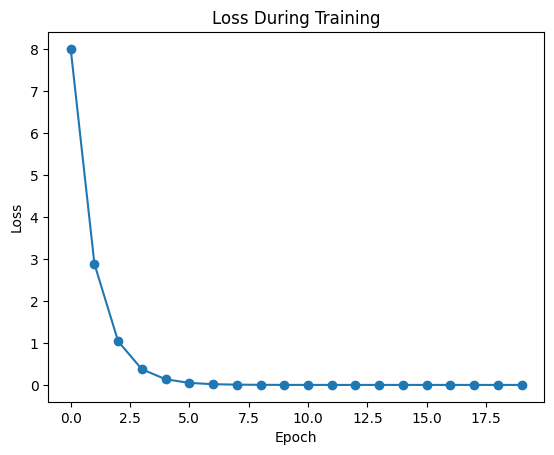

In [15]:
plt.plot(loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss During Training")

plt.show()

In [16]:
gradient = 1.0

vanishing_gradients = []

for layer in range(20):

    gradient = gradient * 0.5

    vanishing_gradients.append(gradient)

print(vanishing_gradients)

[0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625, 0.001953125, 0.0009765625, 0.00048828125, 0.000244140625, 0.0001220703125, 6.103515625e-05, 3.0517578125e-05, 1.52587890625e-05, 7.62939453125e-06, 3.814697265625e-06, 1.9073486328125e-06, 9.5367431640625e-07]


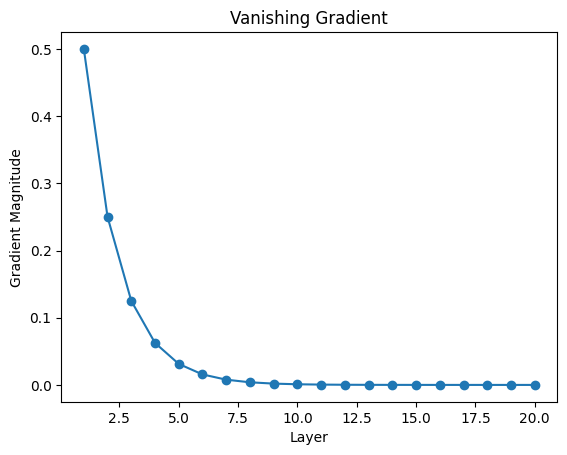

In [17]:
layers = np.arange(1, 21)

plt.plot(
    layers,
    vanishing_gradients,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing Gradient")

plt.show()

In [18]:
gradient = 1.0

exploding_gradients = []

for layer in range(20):

    gradient = gradient * 1.5

    exploding_gradients.append(gradient)

print(exploding_gradients)

[1.5, 2.25, 3.375, 5.0625, 7.59375, 11.390625, 17.0859375, 25.62890625, 38.443359375, 57.6650390625, 86.49755859375, 129.746337890625, 194.6195068359375, 291.92926025390625, 437.8938903808594, 656.8408355712891, 985.2612533569336, 1477.8918800354004, 2216.8378200531006, 3325.256730079651]


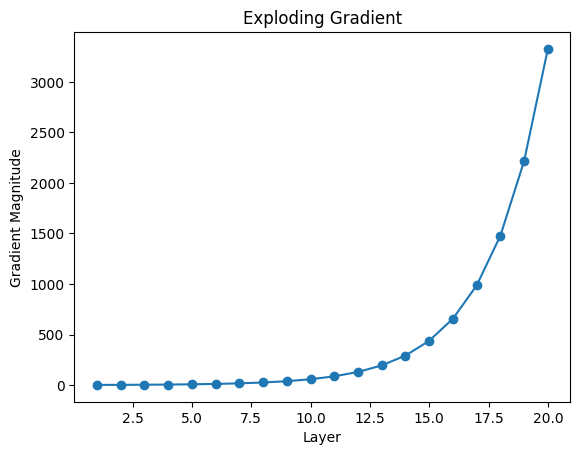

In [19]:
plt.plot(
    layers,
    exploding_gradients,
    marker="o"
)

plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Exploding Gradient")

plt.show()

In [20]:
layers = np.arange(1, 21)

vanishing = 0.5 ** layers
exploding = 1.5 ** layers

print("Layer | Vanishing | Exploding")

for i in range(20):
    print(
        f"{layers[i]:5d} | "
        f"{vanishing[i]:9.6f} | "
        f"{exploding[i]:9.6f}"
    )

Layer | Vanishing | Exploding
    1 |  0.500000 |  1.500000
    2 |  0.250000 |  2.250000
    3 |  0.125000 |  3.375000
    4 |  0.062500 |  5.062500
    5 |  0.031250 |  7.593750
    6 |  0.015625 | 11.390625
    7 |  0.007812 | 17.085938
    8 |  0.003906 | 25.628906
    9 |  0.001953 | 38.443359
   10 |  0.000977 | 57.665039
   11 |  0.000488 | 86.497559
   12 |  0.000244 | 129.746338
   13 |  0.000122 | 194.619507
   14 |  0.000061 | 291.929260
   15 |  0.000031 | 437.893890
   16 |  0.000015 | 656.840836
   17 |  0.000008 | 985.261253
   18 |  0.000004 | 1477.891880
   19 |  0.000002 | 2216.837820
   20 |  0.000001 | 3325.256730


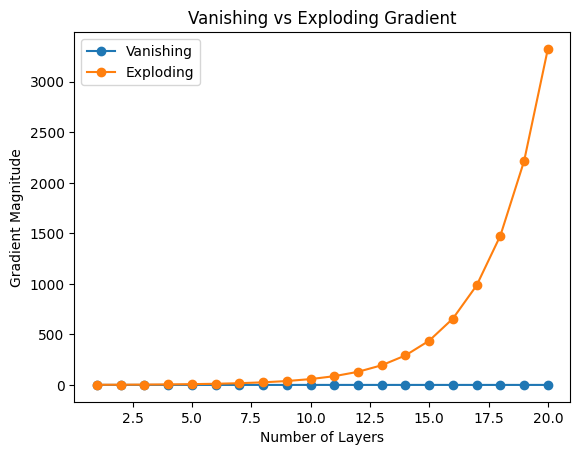

In [21]:
plt.plot(
    layers,
    vanishing,
    marker="o",
    label="Vanishing"
)

plt.plot(
    layers,
    exploding,
    marker="o",
    label="Exploding"
)

plt.xlabel("Number of Layers")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing vs Exploding Gradient")

plt.legend()
plt.show()

In [22]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [23]:
x = np.array([-5, -2, 0, 2, 5])

print(sigmoid(x))

[0.00669285 0.11920292 0.5        0.88079708 0.99330715]


In [24]:
def sigmoid_derivative(x):

    s = sigmoid(x)

    return s * (1 - s)

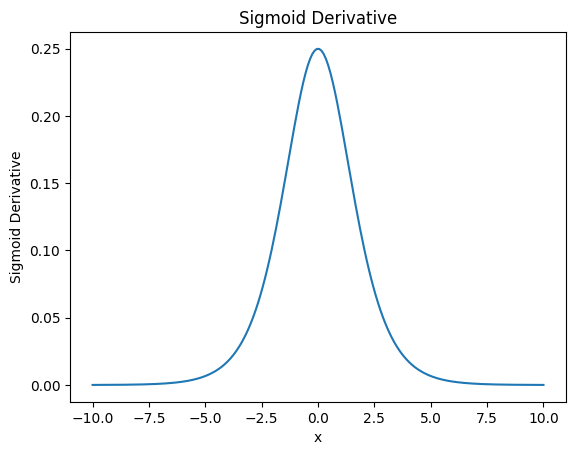

In [25]:
x = np.linspace(-10, 10, 200)

derivative = sigmoid_derivative(x)

plt.plot(x, derivative)

plt.xlabel("x")
plt.ylabel("Sigmoid Derivative")
plt.title("Sigmoid Derivative")

plt.show()

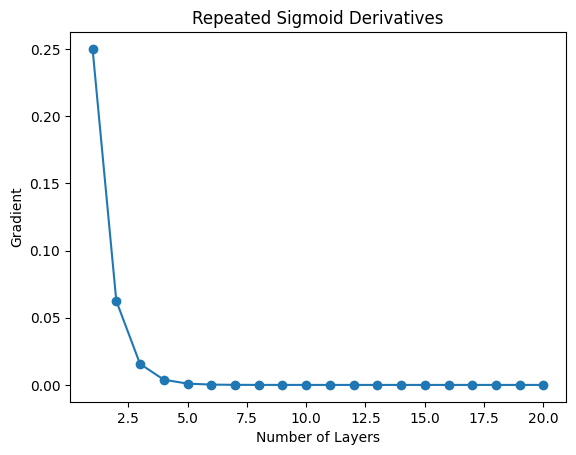

In [26]:
layers = np.arange(1, 21)

sigmoid_gradient = 0.25 ** layers

plt.plot(
    layers,
    sigmoid_gradient,
    marker="o"
)

plt.xlabel("Number of Layers")
plt.ylabel("Gradient")
plt.title("Repeated Sigmoid Derivatives")

plt.show()

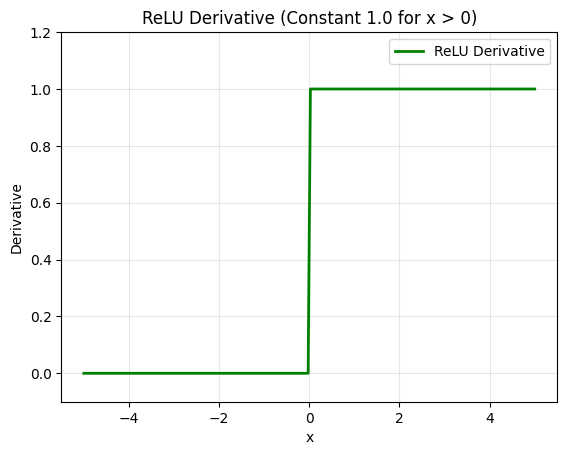

In [29]:

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1.0, 0.0)

# 2. Derivative plot karo
x = np.linspace(-5, 5, 200)
plt.plot(x, relu_derivative(x), color="green", linewidth=2, label="ReLU Derivative")
plt.xlabel("x")
plt.ylabel("Derivative")
plt.title("ReLU Derivative (Constant 1.0 for x > 0)")
plt.ylim(-0.1, 1.2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [28]:
gradient = np.array([3.0, 4.0])

norm = np.linalg.norm(gradient)

print("Gradient:", gradient)
print("Gradient norm:", norm)

Gradient: [3. 4.]
Gradient norm: 5.0


In [30]:
gradient = np.array([3.0, 4.0])

max_norm = 2.0

norm = np.linalg.norm(gradient)

if norm > max_norm:
    clipped_gradient = gradient * (max_norm / norm)
else:
    clipped_gradient = gradient

print("Original Gradient:", gradient)
print("Original Norm:", norm)
print("Clipped Gradient:", clipped_gradient)
print("Clipped Norm:", np.linalg.norm(clipped_gradient))

Original Gradient: [3. 4.]
Original Norm: 5.0
Clipped Gradient: [1.2 1.6]
Clipped Norm: 2.0


In [31]:
def clip_gradient(gradient, max_norm):
    norm = np.linalg.norm(gradient)

    if norm > max_norm:
        gradient = gradient * (max_norm / norm)

    return gradient

In [32]:
gradient = np.array([6.0, 8.0])

clipped = clip_gradient(gradient, max_norm=5.0)

print("Original:", gradient)
print("Original Norm:", np.linalg.norm(gradient))
print("Clipped:", clipped)
print("Clipped Norm:", np.linalg.norm(clipped))

Original: [6. 8.]
Original Norm: 10.0
Clipped: [3. 4.]
Clipped Norm: 5.0


In [33]:
def propagate_gradient(initial_gradient, factor, layers):
    gradient = initial_gradient
    history = []

    for _ in range(layers):
        gradient = gradient * factor
        history.append(abs(gradient))

    return history

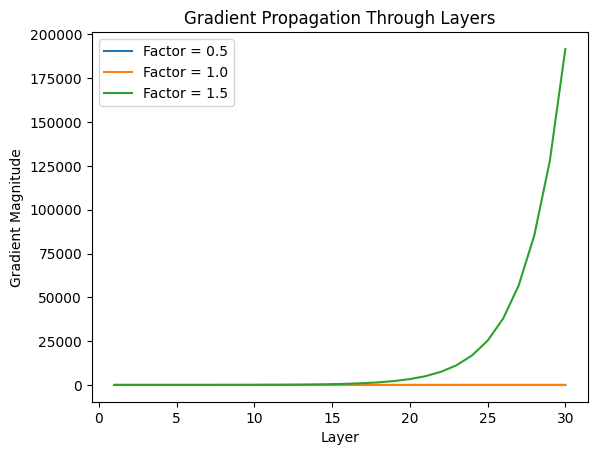

In [34]:
layers = 30

vanishing = propagate_gradient(1.0, 0.5, layers)
stable = propagate_gradient(1.0, 1.0, layers)
exploding = propagate_gradient(1.0, 1.5, layers)

plt.plot(range(1, layers + 1), vanishing, label="Factor = 0.5")
plt.plot(range(1, layers + 1), stable, label="Factor = 1.0")
plt.plot(range(1, layers + 1), exploding, label="Factor = 1.5")

plt.xlabel("Layer")
plt.ylabel("Gradient Magnitude")
plt.title("Gradient Propagation Through Layers")
plt.legend()
plt.show()

In [35]:
gradient_history = []
gradient = 1.0

for layer in range(20):
    gradient = gradient * 1.5
    gradient_history.append(abs(gradient))

    print(
        f"Layer {layer + 1:2d} | "
        f"Gradient Norm = {abs(gradient):.4f}"
    )

Layer  1 | Gradient Norm = 1.5000
Layer  2 | Gradient Norm = 2.2500
Layer  3 | Gradient Norm = 3.3750
Layer  4 | Gradient Norm = 5.0625
Layer  5 | Gradient Norm = 7.5938
Layer  6 | Gradient Norm = 11.3906
Layer  7 | Gradient Norm = 17.0859
Layer  8 | Gradient Norm = 25.6289
Layer  9 | Gradient Norm = 38.4434
Layer 10 | Gradient Norm = 57.6650
Layer 11 | Gradient Norm = 86.4976
Layer 12 | Gradient Norm = 129.7463
Layer 13 | Gradient Norm = 194.6195
Layer 14 | Gradient Norm = 291.9293
Layer 15 | Gradient Norm = 437.8939
Layer 16 | Gradient Norm = 656.8408
Layer 17 | Gradient Norm = 985.2613
Layer 18 | Gradient Norm = 1477.8919
Layer 19 | Gradient Norm = 2216.8378
Layer 20 | Gradient Norm = 3325.2567
